# Neural-network segmentation pipeline

This notebook implements the full supervised segmentation workflow used to train, optimize, and evaluate the neural-network model for cell segmentation from two photon microscopy images. The analysis includes dataset loading, group-aware splitting, preprocessing and augmentation, U-Net model definition, staged transfer-learning, hyperparameter optimization, threshold selection, final held-out test evaluation, and qualitative output inspection.

The aim of this workflow is to obtain a segmentation model that generalizes across heterogeneous image acquisitions while limiting information leakage between related fields of view. When repeating this analysis, the key elements that must remain consistent are the grouping strategy used for splitting, the preprocessing steps applied to images and masks, and the validation-based procedure used for model selection and threshold optimization.

### Required packages

This section installs and imports the Python packages required for model training, image preprocessing, augmentation, evaluation, and plotting. If the notebook is being run in a new environment, missing packages should be installed before continuing.

The main libraries used in this workflow are PyTorch for model training and tensor operations (Paszke et al., 2019 [5]), Albumentations for data augmentation (Buslaev et al., 2020 [6]), Segmentation Models PyTorch for the implementation of the U-Net architecture (Iakubovskii, 2019 [2]), and Optuna for hyperparameter optimization (Akiba et al., 2019 [9]).

```bash
pip install numpy pandas matplotlib opencv-python torch scikit-learn albumentations segmentation-models-pytorch optuna natsort
```

In [1]:
import os
import re
import gc
import json
import copy
import random
from datetime import datetime
from pathlib import Path
from collections import defaultdict

import cv2
import tifffile as tiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
import matplotlib.patheffects as pe
from scipy.optimize import curve_fit

import albumentations as A
from albumentations.pytorch import ToTensorV2

import optuna
import segmentation_models_pytorch as smp


/home/davide/conda-envs/suite2p/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration

This section sets the main file paths, output folders, random seeds, and global constants used throughout the notebook. These settings control where images, masks, split tables, and training outputs are read from and saved.

When repeating the analysis, this is one of the first sections that usually needs to be updated. In particular, the dataset paths, output directories, and any file names linked to grouping tables or saved results should be checked carefully before running the rest of the notebook.


In [2]:
# Paths
# Change this to the folder containing the raw input images
Img_dir = Path('./Images_raw')

# Change this to the folder containing the corresponding segmentation masks
mask_dir = Path('./Masks')

# Change this to the CSV file containing the image similarity groups used for group-aware splitting
groups_csv_path = Path('./image_similarity_groups.csv')

# Output folder where training results, plots, and saved models will be written
output_dir = Path('./semantic_segmentation_output')
output_dir.mkdir(parents=True, exist_ok=True)


# Global configuration
seed = 28
input_size = 512
block_size = 6
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
num_workers = 0
encoder_name = 'resnet50'
encoder_weights = 'imagenet'
thresholds_to_try = [round(x, 2) for x in np.arange(0.25, 0.80, 0.05)]
default_min_mask_area = 16


# Deep hyperparameter search configuration
n_trials = 70
search_timeout_seconds = 1.5 * 3600
top_k_trials_to_plot = 5
hpo_dir = output_dir / 'hyperparameter_search'
hpo_dir.mkdir(parents=True, exist_ok=True)
search_space = {
    'batch_size': [4, 6, 8, 10],
    'freeze_epochs': [6, 8, 10, 12],
    'finetune_epochs': [16, 20, 24, 30, 36],
    'patience': [4, 5, 6, 8],
    'min_mask_area': [0, 8, 16, 24, 32, 48],
}

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)
print('Output folder:', output_dir.resolve())
print('HPO folder:', hpo_dir.resolve())


Using device: cuda
Output folder: /home/davide/Training_Unet_2p_semantic_segmentation/semantic_segmentation_output
HPO folder: /home/davide/Training_Unet_2p_semantic_segmentation/semantic_segmentation_output/hyperparameter_search


### Reproducibility

The full pipeline is seeded before any splitting, loading, or optimization step. Python, NumPy, and PyTorch random states are synchronized, and the DataLoader workers inherit deterministic seeds derived from the same global seed.


In [3]:
def seed_everything(seed: int = 28):
    os.environ['PYTHONHASHseed'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as exc:
        print('Warning: deterministic algorithms could not be fully enforced:', exc)

def seed_worker(worker_id: int):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def build_generator(seed_value):
    generator = torch.Generator()
    generator.manual_seed(seed_value)
    return generator

seed_everything(seed)
generator = build_generator(seed)

### Load metadata and define group-aware dataset splitting

This section loads the image metadata and applies the group-aware train, validation, and test split. The purpose of this step is to keep visually similar fields of view within the same subset and reduce information leakage during model development. The split is performed with a fixed seed so that the partition is reproducible.

When repeating the analysis, the grouping table must be checked carefully. The resulting split sizes should also be inspected, since exact proportions can shift slightly when grouping is enforced at the group level rather than the image level. This group-aware strategy is central to the interpretation of the reported train, validation, and test performance

In [4]:
def extract_numeric_key(pathlike):
    name = Path(pathlike).name
    nums = re.findall(r'\d+', name)
    return int(nums[-1]) if nums else -1

all_imgs = [
    p.name for p in Img_dir.iterdir()
    if p.suffix.lower() in {'.tif', '.tiff', '.png', '.jpg', '.jpeg'}
]
all_imgs = sorted(all_imgs, key=extract_numeric_key)
all_imgs_np = np.array(all_imgs)

groups_df = pd.read_csv(groups_csv_path)
name_to_group = dict(zip(groups_df['file'], groups_df['group_id']))
group_ids = np.array([name_to_group[name] for name in all_imgs], dtype=int)

splitter_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=train_ratio,
    random_state=seed,
)
train_idx, temp_idx = next(splitter_1.split(all_imgs_np, groups=group_ids))
train_names = all_imgs_np[train_idx].tolist()
temp_names = all_imgs_np[temp_idx].tolist()
temp_groups = group_ids[temp_idx]

relative_val_ratio = val_ratio / (val_ratio + test_ratio)

splitter_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=relative_val_ratio,
    random_state=seed,
)
val_sub_idx, test_sub_idx = next(splitter_2.split(np.array(temp_names), groups=temp_groups))
val_names = np.array(temp_names)[val_sub_idx].tolist()
test_names = np.array(temp_names)[test_sub_idx].tolist()
train_group_set = set(name_to_group[x] for x in train_names)
val_group_set = set(name_to_group[x] for x in val_names)
test_group_set = set(name_to_group[x] for x in test_names)

print(f'Total images: {len(all_imgs)}')
print(f'Train: {len(train_names)} | Val: {len(val_names)} | Test: {len(test_names)}')
print(f'Unique groups total: {len(np.unique(group_ids))}')
print(f'Unique train groups: {len(train_group_set)}')
print(f'Unique val groups: {len(val_group_set)}')
print(f'Unique test groups: {len(test_group_set)}')

split_info = {
    'seed': seed,
    'groups_csv': str(groups_csv_path),
    'train_ratio': train_ratio,
    'val_ratio': val_ratio,
    'test_ratio': test_ratio,
    'train_names': train_names,
    'val_names': val_names,
    'test_names': test_names,
    'train_group_ids': sorted(train_group_set),
    'val_group_ids': sorted(val_group_set),
    'test_group_ids': sorted(test_group_set),
}

with open(output_dir / 'split_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(split_info, f, indent=2)

split_info

Total images: 100
Train: 73 | Val: 15 | Test: 12
Unique groups total: 46
Unique train groups: 32
Unique val groups: 7
Unique test groups: 7


{'seed': 28,
 'groups_csv': 'image_similarity_groups.csv',
 'train_ratio': 0.7,
 'val_ratio': 0.15,
 'test_ratio': 0.15,
 'train_names': ['img_003.tif',
  'img_004.tif',
  'img_005.tif',
  'img_006.tif',
  'img_007.tif',
  'img_008.tif',
  'img_009.tif',
  'img_010.tif',
  'img_013.tif',
  'img_014.tif',
  'img_015.tif',
  'img_016.tif',
  'img_017.tif',
  'img_018.tif',
  'img_019.tif',
  'img_020.tif',
  'img_038.tif',
  'img_048.tif',
  'img_049.tif',
  'img_050.tif',
  'img_051.tif',
  'img_067.tif',
  'img_068.tif',
  'img_069.tif',
  'img_070.tif',
  'img_071.tif',
  'img_072.tif',
  'img_073.tif',
  'img_074.tif',
  'img_075.tif',
  'img_076.tif',
  'img_077.tif',
  'img_078.tif',
  'img_079.tif',
  'img_080.tif',
  'img_081.tif',
  'img_082.tif',
  'img_095.tif',
  'img_097.tif',
  'img_098.tif',
  'img_099.tif',
  'img_100.tif',
  'img_103.tif',
  'img_104.tif',
  'img_105.tif',
  'img_106.tif',
  'img_107.tif',
  'img_124.tif',
  'img_136.tif',
  'img_137.tif',
  'img_138.tif

### Data augmentation and preprocessing

This section defines the preprocessing pipeline applied to the images and masks before training. Images are converted to floating point, rescaled, resized to the fixed model input size, and normalized. Training images are additionally subjected to stochastic augmentation, while validation and test images use deterministic preprocessing only. The augmentation pipeline is implemented using Albumentations (Buslaev et al., 2020 [6]). 

In [5]:
def build_train_transform(config=None):
    config = config or {}
    rotate_limit = config.get('rotate_limit', 15)
    brightness_limit = config.get('brightness_limit', 0.08)
    contrast_limit = config.get('contrast_limit', 0.08)
    noise_p = config.get('noise_p', 0.01)

    return A.Compose([
        A.Resize(input_size, input_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent=(-0.05, 0.05),
            scale=(0.90, 1.10),
            rotate=(-rotate_limit, rotate_limit),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=brightness_limit,
            contrast_limit=contrast_limit,
            p=0.3,
        ),
        A.GaussNoise(p=noise_p),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), max_pixel_value=1.0),
        ToTensorV2(),
    ])


def build_val_transform():
    return A.Compose([
        A.Resize(input_size, input_size),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), max_pixel_value=1.0),
        ToTensorV2(),
    ])


train_transform = build_train_transform()
val_transform = build_val_transform()


### Dataset class and DataLoader construction

This section implements the custom dataset class and the DataLoaders used to feed images and masks into the network. Single-channel fluorescence images are replicated into three channels because the encoder expects three-channel input, while masks are binarized and returned with an explicit channel dimension. The dataset and dataloader logic are implemented using PyTorch (Paszke et al., 2019 [5]). Training DataLoaders should shuffle data, whereas validation and test DataLoaders should remain deterministic for reproducible evaluation.

In [6]:
class CellDataset(Dataset):
    def __init__(self, img_dir, mask_dir, names, transform=None):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.names = list(names)
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        img_path = self.img_dir / name
        stem = Path(name).stem
        suffix = Path(name).suffix
        mask_name = f'{stem}_mask{suffix}'
        mask_path = self.mask_dir / mask_name

        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_path}')
        if not mask_path.exists():
            raise FileNotFoundError(f'Mask not found: {mask_path}')

        image = tiff.imread(str(img_path))
        mask = tiff.imread(str(mask_path))

        if image is None:
            raise ValueError(f'Failed to load image: {img_path}')
        if mask is None:
            raise ValueError(f'Failed to load mask: {mask_path}')

        image = image.astype(np.float32)
        if image.max() > 0:
            image = image / 255.0

        if image.ndim == 2:
            image = np.repeat(image[..., None], 3, axis=2)
        elif image.ndim == 3 and image.shape[2] == 1:
            image = np.repeat(image, 3, axis=2)
        elif image.ndim == 3 and image.shape[2] > 3:
            image = image[..., :3]

        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask'].unsqueeze(0)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


def build_dataloaders_from_names(
    train_names_local,
    val_names_local,
    test_names_local,
    batch_size,
    train_transform=None,
    val_transform=None,
    test_batch_size=None,
    generator_seed=None,
):
    train_transform = train_transform or build_train_transform()
    val_transform = val_transform or build_val_transform()
    test_batch_size = batch_size if test_batch_size is None else test_batch_size
    local_generator = build_generator(seed if generator_seed is None else generator_seed)

    trainset = CellDataset(Img_dir, mask_dir, train_names_local, transform=train_transform)
    valset = CellDataset(Img_dir, mask_dir, val_names_local, transform=val_transform)
    testset = CellDataset(Img_dir, mask_dir, test_names_local, transform=val_transform)

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=local_generator,
        pin_memory=torch.cuda.is_available(),
    )

    valloader = DataLoader(
        valset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=local_generator,
        pin_memory=torch.cuda.is_available(),
    )

    testloader = DataLoader(
        testset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=local_generator,
        pin_memory=torch.cuda.is_available(),
    )

    return trainset, valset, testset, trainloader, valloader, testloader


def create_dataloaders(batch_size, train_transform=None, val_transform=None):
    return build_dataloaders_from_names(
        train_names_local=train_names,
        val_names_local=val_names,
        test_names_local=test_names,
        batch_size=batch_size,
        train_transform=train_transform,
        val_transform=val_transform,
        test_batch_size=batch_size,
        generator_seed=seed,
    )


trainset, valset, testset, trainloader, valloader, testloader = create_dataloaders(batch_size=8)
print(f'Train/Val/Test sizes: {len(trainset)} / {len(valset)} / {len(testset)}')


Train/Val/Test sizes: 73 / 15 / 12


### Sanity-check a sample

A single augmented training example is displayed here to verify that image loading, normalization, augmentation, and mask alignment are working as expected before launching training or hyperparameter optimization.


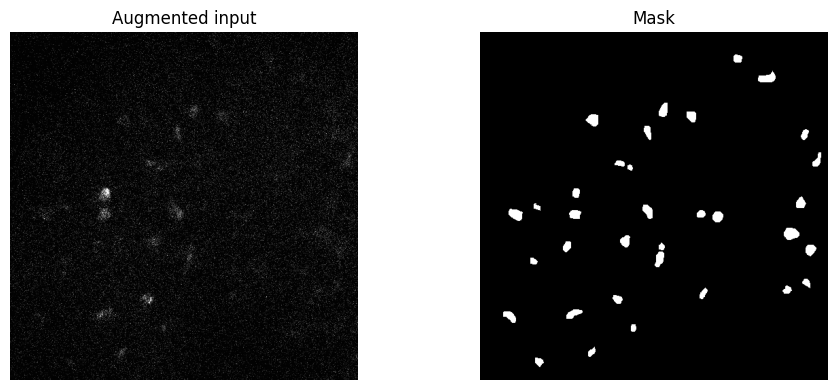

In [7]:
img_tensor, mask_tensor = trainset[1]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_tensor[0].cpu(), cmap='gray')
plt.title('Augmented input')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_tensor[0].cpu(), cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()


### Define the segmentation architecture

This section defines the segmentation model used in the analysis. The architecture is a U-Net (Ronneberger et al., 2015 [1]) implemented with Segmentation Models PyTorch (Iakubovskii, 2019 [2]), using a ResNet-50 encoder (He et al., 2016 [3]) initialized with ImageNet-pretrained weights (Deng et al., 2009 [4]) and configured to output a single-channel logit map for binary foreground segmentation.

In [8]:
def build_model():
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=1,
        decoder_channels=[256, 128, 64, 32, 16],
    )
    return model.to(device)

### Define the composite loss function and optimization strategy

This section defines the training objective and optimizer. The total loss is a weighted combination of binary cross-entropy with logits and Dice loss, with an additional positive-class weighting term to compensate for foreground–background imbalance. Model optimization is performed with AdamW (Loshchilov and Hutter, 2019 [8]) as implemented in PyTorch (Paszke et al., 2019 [5]). The Dice-loss implementation is provided through Segmentation Models PyTorch (Iakubovskii, 2019 [2]) and the BCE follow the PyTorch implementation of binary_cross_entropy_with_logits (Paszke et al., 2019 [5]).

In [9]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=3.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.register_buffer('pos_weight_tensor', torch.tensor(pos_weight, dtype=torch.float32))
        self.dice_loss = smp.losses.DiceLoss(mode='binary')

    def forward(self, logits, targets):
        pos_weight = self.pos_weight_tensor.to(logits.device)
        bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
        dice = self.dice_loss(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5, pos_weight=3.0).to(device)
print('BCEDiceLoss ready')

BCEDiceLoss ready


### Define metric functions and post-processing utilities

This section defines the functions used to convert model outputs into binary masks and to compute segmentation performance metrics such as Dice, IoU, precision, recall, specificity, and accuracy. It may also include post-processing steps such as connected-component filtering to remove very small predicted regions.

In [10]:
def remove_small_components(binary_mask: np.ndarray, min_area: int = 16) -> np.ndarray:
    binary_mask = binary_mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    cleaned = np.zeros_like(binary_mask)
    for label_idx in range(1, num_labels):
        area = stats[label_idx, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label_idx] = 1
    return cleaned


def confusion_from_logits(logits, target, threshold=0.5, min_area=0):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()

    tp = fp = fn = tn = 0
    batch_size = probs.shape[0]

    for i in range(batch_size):
        pred_i = (probs[i, 0] >= threshold).astype(np.uint8)
        if min_area > 0:
            pred_i = remove_small_components(pred_i, min_area=min_area)
        gt_i = (target_np[i, 0] > 0.5).astype(np.uint8)

        tp += int(((pred_i == 1) & (gt_i == 1)).sum())
        fp += int(((pred_i == 1) & (gt_i == 0)).sum())
        fn += int(((pred_i == 0) & (gt_i == 1)).sum())
        tn += int(((pred_i == 0) & (gt_i == 0)).sum())

    return tp, fp, fn, tn


def metrics_from_confusion(tp, fp, fn, tn, eps=1e-8):
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    specificity = (tn + eps) / (tn + fp + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)
    return {
        'dice': float(dice),
        'iou': float(iou),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'accuracy': float(accuracy),
    }


def evaluate_loader(model, loader, criterion, threshold=0.5, min_area=0):
    model.eval()
    running_loss = 0.0
    tp = fp = fn = tn = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            running_loss += loss.item()

            batch_tp, batch_fp, batch_fn, batch_tn = confusion_from_logits(
                logits, masks, threshold=threshold, min_area=min_area
            )
            tp += batch_tp
            fp += batch_fp
            fn += batch_fn
            tn += batch_tn

    avg_loss = running_loss / max(len(loader), 1)
    metrics = metrics_from_confusion(tp, fp, fn, tn)
    metrics['loss'] = float(avg_loss)
    metrics['tp'] = int(tp)
    metrics['fp'] = int(fp)
    metrics['fn'] = int(fn)
    metrics['tn'] = int(tn)
    return metrics


### Define staged training and early stopping

This section implements the two-stage transfer-learning strategy. In the first stage, the encoder is frozen and only the decoder and segmentation head are trained. In the second stage, the encoder is unfrozen and the full model is fine-tuned jointly. Validation Dice is used to monitor performance and trigger early stopping. The training framework is implemented in PyTorch (Paszke et al., 2019 [5]).

In [11]:
def make_logger(log_path: Path):
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def _log(message: str):
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        line = f'[{timestamp}] {message}'
        print(line)
        with open(log_path, 'a', encoding='utf-8') as f:
            f.write(line + '')
    return _log


def train_model(model, trainloader, valloader, criterion, optimizer, epochs, patience,
                threshold=0.5, min_area=0, stage_name='train', log_fn=None):
    history = []
    best_score = -1.0
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_tp = train_fp = train_fn = train_tn = 0

        for imgs, masks in trainloader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(imgs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            batch_tp, batch_fp, batch_fn, batch_tn = confusion_from_logits(
                logits, masks, threshold=threshold, min_area=min_area
            )
            train_tp += batch_tp
            train_fp += batch_fp
            train_fn += batch_fn
            train_tn += batch_tn

        train_metrics = metrics_from_confusion(train_tp, train_fp, train_fn, train_tn)
        train_metrics['loss'] = float(train_loss / max(len(trainloader), 1))

        val_metrics = evaluate_loader(model, valloader, criterion, threshold=threshold, min_area=min_area)

        epoch_record = {
            'stage': stage_name,
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_dice': train_metrics['dice'],
            'train_iou': train_metrics['iou'],
            'val_loss': val_metrics['loss'],
            'val_dice': val_metrics['dice'],
            'val_iou': val_metrics['iou'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_specificity': val_metrics['specificity'],
        }
        history.append(epoch_record)

        message = (
            f"{stage_name} | Epoch {epoch:02d} | "
            f"TrainLoss={train_metrics['loss']:.4f} | TrainDice={train_metrics['dice']:.4f} | "
            f"ValLoss={val_metrics['loss']:.4f} | ValDice={val_metrics['dice']:.4f} | ValIoU={val_metrics['iou']:.4f}"
        )
        if log_fn is not None:
            log_fn(message)
        else:
            print(message)

        if val_metrics['dice'] > best_score:
            best_score = val_metrics['dice']
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                msg = f'{stage_name} | Early stopping triggered.'
                if log_fn is not None:
                    log_fn(msg)
                else:
                    print(msg)
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def run_two_stage_training(model, trainloader, valloader, criterion,
                           freeze_epochs, finetune_epochs, patience,
                           lr_head, lr_full, weight_decay,
                           threshold=0.5, min_area=0, log_fn=None,
                           frozen_stage_name='frozen_encoder',
                           finetune_stage_name='full_finetuning'):
    for param in model.encoder.parameters():
        param.requires_grad = False

    optimizer_head = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head,
        weight_decay=weight_decay,
    )

    model, history_stage1 = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        criterion=criterion,
        optimizer=optimizer_head,
        epochs=freeze_epochs,
        patience=max(3, patience // 2),
        threshold=threshold,
        min_area=min_area,
        stage_name=frozen_stage_name,
        log_fn=log_fn,
    )

    for param in model.encoder.parameters():
        param.requires_grad = True

    optimizer_full = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full,
        weight_decay=weight_decay,
    )

    model, history_stage2 = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        criterion=criterion,
        optimizer=optimizer_full,
        epochs=finetune_epochs,
        patience=patience,
        threshold=threshold,
        min_area=min_area,
        stage_name=finetune_stage_name,
        log_fn=log_fn,
    )

    if len(history_stage1) > 0:
        history_stage2 = history_stage2.copy()
        history_stage2['epoch'] = history_stage2['epoch'] + int(history_stage1['epoch'].max())

    history_df = pd.concat([history_stage1, history_stage2], ignore_index=True)
    return model, history_stage1, history_stage2, history_df


def evaluate_threshold_grid(model, loader, criterion, thresholds, min_area):
    threshold_results = []
    for thr in thresholds:
        metrics = evaluate_loader(
            model,
            loader,
            criterion,
            threshold=thr,
            min_area=min_area,
        )
        threshold_results.append({
            'threshold': thr,
            'dice': metrics['dice'],
            'iou': metrics['iou'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'specificity': metrics['specificity'],
            'loss': metrics['loss'],
        })

    threshold_df = pd.DataFrame(threshold_results).sort_values(by='dice', ascending=False).reset_index(drop=True)
    best_threshold = float(threshold_df.iloc[0]['threshold'])
    return threshold_df, best_threshold

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


### Define the Optuna hyperparameter search utilities

This section defines the hyperparameter sampling logic and the single-trial training routine used during Optuna optimization. The search includes training parameters, optimizer settings, loss weighting, augmentation settings, and post-processing parameters.H  Hyperparameter optimization is performed with Optuna (Akiba et al., 2019 [9]). 

In [12]:
def sample_hparams(trial):
    bce_weight = trial.suggest_float('bce_weight', 0.20, 0.80)
    config = {
        'batch_size': trial.suggest_categorical('batch_size', search_space['batch_size']),
        'freeze_epochs': trial.suggest_categorical('freeze_epochs', search_space['freeze_epochs']),
        'finetune_epochs': trial.suggest_categorical('finetune_epochs', search_space['finetune_epochs']),
        'patience': trial.suggest_categorical('patience', search_space['patience']),
        'lr_head': trial.suggest_float('lr_head', 1e-4, 3e-3, log=True),
        'lr_full': trial.suggest_float('lr_full', 5e-5, 8e-4, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True),
        'pos_weight': trial.suggest_float('pos_weight', 1.0, 6.0),
        'bce_weight': bce_weight,
        'dice_weight': 1.0 - bce_weight,
        'min_mask_area': trial.suggest_categorical('min_mask_area', search_space['min_mask_area']),
        'rotate_limit': trial.suggest_int('rotate_limit', 5, 25),
        'brightness_limit': trial.suggest_float('brightness_limit', 0.02, 0.15),
        'contrast_limit': trial.suggest_float('contrast_limit', 0.02, 0.15),
        'noise_p': trial.suggest_float('noise_p', 0.0, 0.08),
    }
    return config


def run_single_trial(config, trial_number):
    trial_dir = hpo_dir / f'trial_{trial_number:04d}'
    trial_dir.mkdir(parents=True, exist_ok=True)
    log_fn = make_logger(trial_dir / 'run.log')

    seed_everything(seed)
    train_transform = build_train_transform(config)
    val_transform = build_val_transform()
    trainset, valset, testset, trainloader, valloader, testloader = create_dataloaders(
        batch_size=config['batch_size'],
        train_transform=train_transform,
        val_transform=val_transform,
    )

    criterion = BCEDiceLoss(
        bce_weight=config['bce_weight'],
        dice_weight=config['dice_weight'],
        pos_weight=config['pos_weight'],
    ).to(device)
    model = build_model()

    log_fn(f'Trial {trial_number} started')
    log_fn(json.dumps(config, indent=2))

    model, history_stage1, history_stage2, history_df = run_two_stage_training(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        criterion=criterion,
        freeze_epochs=config['freeze_epochs'],
        finetune_epochs=config['finetune_epochs'],
        patience=config['patience'],
        lr_head=config['lr_head'],
        lr_full=config['lr_full'],
        weight_decay=config['weight_decay'],
        threshold=0.5,
        min_area=0,
        log_fn=log_fn,
        frozen_stage_name='frozen_encoder',
        finetune_stage_name='full_finetuning',
    )

    history_stage1.to_csv(trial_dir / 'history_stage1.csv', index=False)
    history_stage2.to_csv(trial_dir / 'history_stage2.csv', index=False)
    history_df.to_csv(trial_dir / 'history_full.csv', index=False)

    threshold_df, best_threshold = evaluate_threshold_grid(
        model=model,
        loader=valloader,
        criterion=criterion,
        thresholds=thresholds_to_try,
        min_area=config['min_mask_area'],
    )
    threshold_df.to_csv(trial_dir / 'validation_threshold_search.csv', index=False)
    best_val_dice = float(threshold_df.iloc[0]['dice'])

    final_val_metrics = evaluate_loader(
        model,
        valloader,
        criterion,
        threshold=best_threshold,
        min_area=config['min_mask_area'],
    )

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'seed': seed,
        'input_size': input_size,
        'encoder_name': encoder_name,
        'encoder_weights': encoder_weights,
        'best_threshold': best_threshold,
        'min_mask_area': config['min_mask_area'],
        'train_names': train_names,
        'val_names': val_names,
        'test_names': test_names,
        'hyperparameters': config,
        'trial_number': trial_number,
        'final_val_metrics': final_val_metrics,
    }
    torch.save(checkpoint, trial_dir / 'best_model.pth')

    trial_summary = {
        'trial_number': trial_number,
        'trial_dir': str(trial_dir.resolve()),
        'batch_size': config['batch_size'],
        'freeze_epochs': config['freeze_epochs'],
        'finetune_epochs': config['finetune_epochs'],
        'patience': config['patience'],
        'lr_head': config['lr_head'],
        'lr_full': config['lr_full'],
        'weight_decay': config['weight_decay'],
        'pos_weight': config['pos_weight'],
        'bce_weight': config['bce_weight'],
        'dice_weight': config['dice_weight'],
        'min_mask_area': config['min_mask_area'],
        'rotate_limit': config['rotate_limit'],
        'brightness_limit': config['brightness_limit'],
        'contrast_limit': config['contrast_limit'],
        'noise_p': config['noise_p'],
        'best_threshold': best_threshold,
        'best_val_dice': best_val_dice,
        'best_val_iou': float(final_val_metrics['iou']),
        'best_val_precision': float(final_val_metrics['precision']),
        'best_val_recall': float(final_val_metrics['recall']),
        'best_val_specificity': float(final_val_metrics['specificity']),
        'best_val_loss': float(final_val_metrics['loss']),
        'num_train_images': len(trainset),
        'num_val_images': len(valset),
        'num_test_images': len(testset),
        'device': str(device),
        'timestamp_utc': datetime.utcnow().isoformat(),
    }

    with open(trial_dir / 'trial_summary.json', 'w', encoding='utf-8') as f:
        json.dump(trial_summary, f, indent=2)

    log_fn(f'Trial {trial_number} completed with best validation Dice = {best_val_dice:.6f}')

    del model, criterion, trainloader, valloader, testloader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return trial_summary

### Run hyperparameter optimization and save trial summaries

This section creates the Optuna study, defines the objective function, launches the optimization, and saves the resulting metrics and selected parameters for later inspection. Each trial corresponds to a full model-training run under one sampled hyperparameter configuration.

In [ ]:
seed_everything(seed)
sampler = optuna.samplers.TPESampler(seed=seed)
study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='u_net_resnet50_segmentation_hpo',
)

all_trial_rows = []

def objective(trial):
    config = sample_hparams(trial)
    summary = run_single_trial(config=config, trial_number=trial.number)
    all_trial_rows.append(summary)
    for key, value in summary.items():
        if isinstance(value, (int, float, str, bool)):
            trial.set_user_attr(key, value)
    return summary['best_val_dice']

study.optimize(objective, n_trials=n_trials, timeout=search_timeout_seconds, gc_after_trial=True)
trials_df = pd.DataFrame(all_trial_rows).sort_values(by='best_val_dice', ascending=False).reset_index(drop=True)
trials_df.to_csv(hpo_dir / 'all_trials_summary.csv', index=False)

with open(hpo_dir / 'best_trial_summary.json', 'w', encoding='utf-8') as f:
    json.dump(trials_df.iloc[0].to_dict(), f, indent=2, default=str)

print('Best trial number:', int(trials_df.iloc[0]['trial_number']))
print('Best validation Dice:', float(trials_df.iloc[0]['best_val_dice']))
trials_df.head(10)


[I 2026-04-29 17:22:55,345] A new study created in memory with name: u_net_resnet50_segmentation_hpo


[2026-04-29 17:22:55] Trial 0 started
[2026-04-29 17:22:55] {
  "batch_size": 10,
  "freeze_epochs": 12,
  "finetune_epochs": 16,
  "patience": 4,
  "lr_head": 0.0003837845446475663,
  "lr_full": 0.00020600494076527176,
  "weight_decay": 6.782397512065425e-06,
  "pos_weight": 3.147844167959688,
  "bce_weight": 0.6374082453734715,
  "dice_weight": 0.3625917546265285,
  "min_mask_area": 24,
  "rotate_limit": 21,
  "brightness_limit": 0.039419884965048925,
  "contrast_limit": 0.1142961577542297,
  "noise_p": 0.07641171474540695
}
[2026-04-29 17:22:58] frozen_encoder | Epoch 01 | TrainLoss=0.7609 | TrainDice=0.0673 | ValLoss=0.7377 | ValDice=0.0213 | ValIoU=0.0108
[2026-04-29 17:23:00] frozen_encoder | Epoch 02 | TrainLoss=0.6572 | TrainDice=0.3053 | ValLoss=0.6439 | ValDice=0.2243 | ValIoU=0.1263
[2026-04-29 17:23:02] frozen_encoder | Epoch 03 | TrainLoss=0.5918 | TrainDice=0.4835 | ValLoss=0.5912 | ValDice=0.4399 | ValIoU=0.2820
[2026-04-29 17:23:04] frozen_encoder | Epoch 04 | TrainLoss

[I 2026-04-29 17:23:38,266] Trial 0 finished with value: 0.6908088527983749 and parameters: {'bce_weight': 0.6374082453734715, 'batch_size': 10, 'freeze_epochs': 12, 'finetune_epochs': 16, 'patience': 4, 'lr_head': 0.0003837845446475663, 'lr_full': 0.00020600494076527176, 'weight_decay': 6.782397512065425e-06, 'pos_weight': 3.147844167959688, 'min_mask_area': 24, 'rotate_limit': 21, 'brightness_limit': 0.039419884965048925, 'contrast_limit': 0.1142961577542297, 'noise_p': 0.07641171474540695}. Best is trial 0 with value: 0.6908088527983749.


[2026-04-29 17:23:38] Trial 1 started
[2026-04-29 17:23:38] {
  "batch_size": 6,
  "freeze_epochs": 6,
  "finetune_epochs": 24,
  "patience": 6,
  "lr_head": 0.0007972740026785037,
  "lr_full": 0.00012040876299965923,
  "weight_decay": 0.0001148235972229002,
  "pos_weight": 1.7814104079183877,
  "bce_weight": 0.24385746485957607,
  "dice_weight": 0.756142535140424,
  "min_mask_area": 0,
  "rotate_limit": 17,
  "brightness_limit": 0.13386041859764167,
  "contrast_limit": 0.1496265933165453,
  "noise_p": 0.022024507344343452
}
[2026-04-29 17:23:40] frozen_encoder | Epoch 01 | TrainLoss=0.8337 | TrainDice=0.1420 | ValLoss=0.8128 | ValDice=0.1406 | ValIoU=0.0756
[2026-04-29 17:23:43] frozen_encoder | Epoch 02 | TrainLoss=0.7325 | TrainDice=0.4714 | ValLoss=0.7378 | ValDice=0.5306 | ValIoU=0.3611
[2026-04-29 17:23:45] frozen_encoder | Epoch 03 | TrainLoss=0.6541 | TrainDice=0.5658 | ValLoss=0.6683 | ValDice=0.5549 | ValIoU=0.3840
[2026-04-29 17:23:47] frozen_encoder | Epoch 04 | TrainLoss=0

[I 2026-04-29 17:24:41,528] Trial 1 finished with value: 0.7296190388340809 and parameters: {'bce_weight': 0.24385746485957607, 'batch_size': 6, 'freeze_epochs': 6, 'finetune_epochs': 24, 'patience': 6, 'lr_head': 0.0007972740026785037, 'lr_full': 0.00012040876299965923, 'weight_decay': 0.0001148235972229002, 'pos_weight': 1.7814104079183877, 'min_mask_area': 0, 'rotate_limit': 17, 'brightness_limit': 0.13386041859764167, 'contrast_limit': 0.1496265933165453, 'noise_p': 0.022024507344343452}. Best is trial 1 with value: 0.7296190388340809.


...

[2026-04-29 18:03:08] Trial 38 started
[2026-04-29 18:03:08] {
  "batch_size": 10,
  "freeze_epochs": 12,
  "finetune_epochs": 24,
  "patience": 8,
  "lr_head": 0.0014984530446199237,
  "lr_full": 0.00022975933759687543,
  "weight_decay": 1.4063625703297059e-05,
  "pos_weight": 3.190315318405861,
  "bce_weight": 0.2617624111053385,
  "dice_weight": 0.7382375888946615,
  "min_mask_area": 24,
  "rotate_limit": 13,
  "brightness_limit": 0.05669181273635073,
  "contrast_limit": 0.06186836729350425,
  "noise_p": 0.07046478392344416
}
[2026-04-29 18:03:11] frozen_encoder | Epoch 01 | TrainLoss=0.8376 | TrainDice=0.1164 | ValLoss=0.8536 | ValDice=0.0054 | ValIoU=0.0027
[2026-04-29 18:03:13] frozen_encoder | Epoch 02 | TrainLoss=0.7320 | TrainDice=0.4147 | ValLoss=0.7748 | ValDice=0.2208 | ValIoU=0.1241
[2026-04-29 18:03:15] frozen_encoder | Epoch 03 | TrainLoss=0.6451 | TrainDice=0.5428 | ValLoss=0.6714 | ValDice=0.4878 | ValIoU=0.3225
[2026-04-29 18:03:17] frozen_encoder | Epoch 04 | TrainLo

[I 2026-04-29 18:04:06,462] Trial 38 finished with value: 0.7273083670649384 and parameters: {'bce_weight': 0.2617624111053385, 'batch_size': 10, 'freeze_epochs': 12, 'finetune_epochs': 24, 'patience': 8, 'lr_head': 0.0014984530446199237, 'lr_full': 0.00022975933759687543, 'weight_decay': 1.4063625703297059e-05, 'pos_weight': 3.190315318405861, 'min_mask_area': 24, 'rotate_limit': 13, 'brightness_limit': 0.05669181273635073, 'contrast_limit': 0.06186836729350425, 'noise_p': 0.07046478392344416}. Best is trial 24 with value: 0.745938535826846.


[2026-04-29 18:04:06] Trial 39 started
[2026-04-29 18:04:06] {
  "batch_size": 4,
  "freeze_epochs": 6,
  "finetune_epochs": 20,
  "patience": 6,
  "lr_head": 0.0024672791609890014,
  "lr_full": 8.062627290866517e-05,
  "weight_decay": 0.00015714112622623874,
  "pos_weight": 4.467686701506989,
  "bce_weight": 0.36686414305569154,
  "dice_weight": 0.6331358569443084,
  "min_mask_area": 0,
  "rotate_limit": 11,
  "brightness_limit": 0.09109477522347927,
  "contrast_limit": 0.1230221625353377,
  "noise_p": 0.03980948059388985
}
[2026-04-29 18:04:08] frozen_encoder | Epoch 01 | TrainLoss=0.6624 | TrainDice=0.2566 | ValLoss=0.6016 | ValDice=0.4646 | ValIoU=0.3026
[2026-04-29 18:04:11] frozen_encoder | Epoch 02 | TrainLoss=0.3849 | TrainDice=0.6045 | ValLoss=0.3359 | ValDice=0.6271 | ValIoU=0.4568
[2026-04-29 18:04:13] frozen_encoder | Epoch 03 | TrainLoss=0.3203 | TrainDice=0.6153 | ValLoss=0.3163 | ValDice=0.5980 | ValIoU=0.4265
[2026-04-29 18:04:15] frozen_encoder | Epoch 04 | TrainLoss=0

[I 2026-04-29 18:04:40,471] Trial 39 finished with value: 0.7179185623059517 and parameters: {'bce_weight': 0.36686414305569154, 'batch_size': 4, 'freeze_epochs': 6, 'finetune_epochs': 20, 'patience': 6, 'lr_head': 0.0024672791609890014, 'lr_full': 8.062627290866517e-05, 'weight_decay': 0.00015714112622623874, 'pos_weight': 4.467686701506989, 'min_mask_area': 0, 'rotate_limit': 11, 'brightness_limit': 0.09109477522347927, 'contrast_limit': 0.1230221625353377, 'noise_p': 0.03980948059388985}. Best is trial 24 with value: 0.745938535826846.


[2026-04-29 18:04:40] Trial 40 started
[2026-04-29 18:04:40] {
  "batch_size": 6,
  "freeze_epochs": 8,
  "finetune_epochs": 30,
  "patience": 8,
  "lr_head": 0.0007365021559209921,
  "lr_full": 5.0102326459068683e-05,
  "weight_decay": 3.7836599756169517e-06,
  "pos_weight": 1.543506537060221,
  "bce_weight": 0.5138940793039273,
  "dice_weight": 0.4861059206960727,
  "min_mask_area": 32,
  "rotate_limit": 24,
  "brightness_limit": 0.03167312671643445,
  "contrast_limit": 0.13661399712295721,
  "noise_p": 0.05650608780463484
}
[2026-04-29 18:04:43] frozen_encoder | Epoch 01 | TrainLoss=0.7311 | TrainDice=0.1255 | ValLoss=0.6298 | ValDice=0.0230 | ValIoU=0.0116
[2026-04-29 18:04:45] frozen_encoder | Epoch 02 | TrainLoss=0.5943 | TrainDice=0.4828 | ValLoss=0.5863 | ValDice=0.2629 | ValIoU=0.1513
[2026-04-29 18:04:47] frozen_encoder | Epoch 03 | TrainLoss=0.5125 | TrainDice=0.5795 | ValLoss=0.4908 | ValDice=0.5498 | ValIoU=0.3791
[2026-04-29 18:04:49] frozen_encoder | Epoch 04 | TrainLoss

### Hyperparameter-search overview plots

The search results are summarized here with a compact set of plots showing the trajectory of validation Dice across trials, the distribution of top scores, the best-performing trial indices, and the relation between fine-tuning learning rate and validation Dice. A second figure overlays the validation-Dice curves of the best trials to make convergence behavior directly comparable.


In [ ]:
def _safe_read_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return None

def load_trials_from_folder(hpo_dir: Path) -> pd.DataFrame:
    csv_path = hpo_dir / 'all_trials_summary.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        if len(df) > 0:
            return df.sort_values(
                by=['best_val_dice', 'best_val_iou'] if 'best_val_iou' in df.columns else ['best_val_dice'],
                ascending=False,
            ).reset_index(drop=True)

    rows = []
    trial_dirs = sorted([p for p in hpo_dir.iterdir() if p.is_dir() and p.name.startswith('trial_')])

    for trial_dir in trial_dirs:
        candidates = [
            trial_dir / 'summary.json',
            trial_dir / 'metrics.json',
            trial_dir / 'trial_summary.json',
            trial_dir / 'best_trial_summary.json',
            trial_dir / 'config_and_metrics.json',
        ]

        row = None
        for candidate in candidates:
            if candidate.exists():
                row = _safe_read_json(candidate)
                if row is not None:
                    break

        if row is None:
            continue

        if 'trial_number' not in row:
            try:
                row['trial_number'] = int(trial_dir.name.split('_')[-1])
            except Exception:
                pass

        rows.append(row)

    if len(rows) == 0:
        raise FileNotFoundError(
            f'Could not rebuild trial table. Missing: {csv_path} '
            f'and no readable per-trial summary JSON found in {hpo_dir}'
        )

    df = pd.DataFrame(rows)
    sort_cols = ['best_val_dice']
    if 'best_val_iou' in df.columns:
        sort_cols.append('best_val_iou')
    return df.sort_values(by=sort_cols, ascending=False).reset_index(drop=True)

def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, pad=10, weight='semibold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    ax.tick_params(axis='both', which='major', labelsize=10.5, length=4, width=1.0)
    ax.set_axisbelow(True)


primary_color = "#5B6CFF"       
secondary_color = "#F08A5D"     
tertiary_color = "#4C9F70"      
quaternary_color = "#7C83C3"   
highlight_color = "#000000"   


trials_df = load_trials_from_folder(hpo_dir)

if len(trials_df) == 0:
    raise ValueError('No trials found on disk.')
if 'trial_number' not in trials_df.columns:
    raise ValueError('trial_number column not found in rebuilt trials_df.')

best_row = trials_df.iloc[0]
plot_df = trials_df.sort_values('trial_number').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=300)
axes = axes.ravel()

axes[0].plot(
    plot_df['trial_number'],
    plot_df['best_val_dice'],
    marker='o',
    linewidth=2.6,
    color=primary_color,
    alpha=0.98,
    solid_capstyle='round',
    label='Best validation Dice',
)
axes[0].axhline(
    best_row['best_val_dice'],
    color=highlight_color,
    linestyle='--',
    linewidth=1.5,
    alpha=0.50,
    label=f"Best = {best_row['best_val_dice']:.4f}",
)
style_ax(axes[0], 'Validation Dice across trials', 'Trial number', 'Best validation Dice')
axes[0].legend(frameon=False, fontsize=10.5, handlelength=2.4)

axes[1].hist(
    trials_df['best_val_dice'],
    bins=min(12, max(5, len(trials_df) // 2)),
    color=secondary_color,
    edgecolor='white',
    linewidth=1.0,
    alpha=0.95,
)
style_ax(axes[1], 'Distribution of best validation Dice', 'Best validation Dice', 'Count')

top10 = trials_df.head(min(10, len(trials_df))).sort_values('best_val_dice', ascending=True)
axes[2].barh(
    top10['trial_number'].astype(str),
    top10['best_val_dice'],
    color=tertiary_color,
    alpha=0.95,
)
style_ax(axes[2], 'Top trials by validation Dice', 'Best validation Dice', 'Trial number')

if 'lr_full' in trials_df.columns:
    axes[3].scatter(
        trials_df['lr_full'],
        trials_df['best_val_dice'],
        s=55,
        color=quaternary_color,
        alpha=0.90,
    )
    axes[3].set_xscale('log')
    style_ax(axes[3], 'Fine-tuning LR vs validation Dice', 'lr_full', 'Best validation Dice')
else:
    axes[3].text(
        0.5,
        0.5,
        'lr_full not found in saved summaries',
        ha='center',
        va='center',
        fontsize=12,
    )
    axes[3].set_axis_off()

fig.suptitle('Deep hyperparameter-search summary', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig(hpo_dir / 'hpo_overview.png', bbox_inches='tight', dpi=300)
plt.show()

top_trials = trials_df.head(min(top_k_trials_to_plot, len(trials_df))).copy()

plt.figure(figsize=(14, 7), dpi=300)
for i, (_, row) in enumerate(top_trials.iterrows()):
    history_path = Path(row['trial_dir']) / 'history_full.csv'
    hist_df = pd.read_csv(history_path)

    color = primary_color if i == 0 else secondary_color if i == 1 else tertiary_color if i == 2 else quaternary_color

    plt.plot(
        hist_df['epoch'],
        hist_df['val_dice'],
        linewidth=2.4,
        alpha=0.98,
        color=color,
        label=f"trial {int(row['trial_number'])} | Dice={row['best_val_dice']:.4f}",
        solid_capstyle='round',
    )

ax = plt.gca()
style_ax(ax, 'Validation Dice across epochs for the top trials', 'Global epoch', 'Validation Dice')
plt.legend(frameon=False, fontsize=10.5, handlelength=2.4)
plt.tight_layout()
plt.savefig(hpo_dir / 'top_trials_val_dice_overlay.png', bbox_inches='tight', dpi=300)
plt.show()

trials_df.to_csv(hpo_dir / 'all_trials_summary.csv', index=False)
with open(hpo_dir / 'best_trial_summary.json', 'w', encoding='utf-8') as f:
    json.dump(best_row.to_dict(), f, indent=2, default=str)

print('Loaded from folder:', hpo_dir)
print('Number of recovered trials:', len(trials_df))
print('Best trial number:', int(best_row['trial_number']))
print('Best validation Dice:', float(best_row['best_val_dice']))
trials_df.head(10)

### Load the best trial and freeze its outputs as the final model

Once the search is complete, the best trial is reloaded from disk and promoted to the canonical final model for the rest of the notebook. Its training history, validation-threshold table, and selected hyperparameters are copied into the main output directory so that the final analysis no longer depends on navigating individual trial folders.


In [ ]:
best_trial_row = trials_df.iloc[0]
best_trial_dir = Path(best_trial_row['trial_dir'])

history_df = pd.read_csv(best_trial_dir / 'history_full.csv')
threshold_df = pd.read_csv(best_trial_dir / 'validation_threshold_search.csv').sort_values(
    by='dice', ascending=False
).reset_index(drop=True)
best_threshold = float(best_trial_row['best_threshold'])
min_mask_area = int(best_trial_row['min_mask_area'])

ckpt = torch.load(best_trial_dir / 'best_model.pth', map_location=device)
model = build_model()
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

best_config = ckpt['hyperparameters']
criterion = BCEDiceLoss(
    bce_weight=best_config['bce_weight'],
    dice_weight=best_config['dice_weight'],
    pos_weight=best_config['pos_weight'],
).to(device)

train_transform = build_train_transform(best_config)
val_transform = build_val_transform()
trainset, valset, testset, trainloader, valloader, testloader = create_dataloaders(
    batch_size=int(best_trial_row['batch_size']),
    train_transform=train_transform,
    val_transform=val_transform,
)

history_df.to_csv(output_dir / 'training_history.csv', index=False)
threshold_df.to_csv(output_dir / 'validation_threshold_search.csv', index=False)

with open(output_dir / 'selected_best_hyperparameters.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2)

print('Selected trial:', int(best_trial_row['trial_number']))
print('Best validation threshold:', best_threshold)
print('Selected min mask area:', min_mask_area)
threshold_df.head()


### Training curves and threshold selection for the selected best run

The diagnostic plots below summarize the full optimization trajectory of the selected run and the validation-threshold search that determined the final binarization threshold used for held-out test evaluation.


In [ ]:
def style_ax(ax, title, ylabel):
    ax.set_title(title, pad=10, weight='semibold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    ax.tick_params(axis='both', which='major', labelsize=10.5, length=4, width=1.0)
    ax.set_axisbelow(True)

train_color = "#5B6CFF"      
val_color = "#F08A5D"      
precision_color = "#4C9F70" 
recall_color = "#D66A6A"      
specificity_color = "#7C83C3" 
highlight_color = "#000000"   

best_epoch = history_df.loc[history_df['val_dice'].astype(float).idxmax(), 'epoch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
axes = axes.ravel()

axes[0].plot(
    history_df['epoch'], history_df['train_loss'],
    linewidth=2.6, color=train_color, alpha=0.98,
    label='Train loss', solid_capstyle='round'
)
axes[0].plot(
    history_df['epoch'], history_df['val_loss'],
    linewidth=2.6, color=val_color, alpha=0.98,
    label='Validation loss', solid_capstyle='round'
)
axes[0].axvline(best_epoch, color=highlight_color, linestyle='--', linewidth=1.6, alpha=0.50, zorder=1)
style_ax(axes[0], 'Training and Validation Loss', 'Loss')
axes[0].legend(frameon=False, fontsize=10.5, handlelength=2.4)

axes[1].plot(
    history_df['epoch'], history_df['train_dice'],
    linewidth=2.6, color=train_color, alpha=0.98,
    label='Train Dice', solid_capstyle='round'
)
axes[1].plot(
    history_df['epoch'], history_df['val_dice'],
    linewidth=2.6, color=val_color, alpha=0.98,
    label='Validation Dice', solid_capstyle='round'
)
axes[1].axvline(best_epoch, color=highlight_color, linestyle='--', linewidth=1.6, alpha=0.50, zorder=1)
style_ax(axes[1], 'Training and Validation Dice', 'Dice')
axes[1].set_ylim(
    max(0.0, history_df[['train_dice', 'val_dice']].min().min() - 0.03),
    min(1.0, history_df[['train_dice', 'val_dice']].max().max() + 0.03),
)
axes[1].legend(frameon=False, fontsize=10.5, handlelength=2.4)

axes[2].plot(
    history_df['epoch'], history_df['train_iou'],
    linewidth=2.6, color=train_color, alpha=0.98,
    label='Train IoU', solid_capstyle='round'
)
axes[2].plot(
    history_df['epoch'], history_df['val_iou'],
    linewidth=2.6, color=val_color, alpha=0.98,
    label='Validation IoU', solid_capstyle='round'
)
axes[2].axvline(best_epoch, color=highlight_color, linestyle='--', linewidth=1.6, alpha=0.50, zorder=1)
style_ax(axes[2], 'Training and Validation IoU', 'IoU')
axes[2].set_ylim(
    max(0.0, history_df[['train_iou', 'val_iou']].min().min() - 0.03),
    min(1.0, history_df[['train_iou', 'val_iou']].max().max() + 0.03),
)
axes[2].legend(frameon=False, fontsize=10.5, handlelength=2.4)

axes[3].plot(
    history_df['epoch'], history_df['val_precision'],
    linewidth=2.4, color=precision_color, alpha=0.98,
    label='Precision', solid_capstyle='round'
)
axes[3].plot(
    history_df['epoch'], history_df['val_recall'],
    linewidth=2.4, color=recall_color, alpha=0.98,
    label='Recall', solid_capstyle='round'
)
axes[3].plot(
    history_df['epoch'], history_df['val_specificity'],
    linewidth=2.4, color=specificity_color, alpha=0.98,
    label='Specificity', solid_capstyle='round'
)
axes[3].axvline(best_epoch, color=highlight_color, linestyle='--', linewidth=1.6, alpha=0.50, zorder=1)
style_ax(axes[3], 'Validation Semantic Metrics', 'Metric value')
axes[3].set_ylim(
    max(0.0, history_df[['val_precision', 'val_recall', 'val_specificity']].min().min() - 0.03),
    min(1.02, history_df[['val_precision', 'val_recall', 'val_specificity']].max().max() + 0.02),
)
axes[3].legend(frameon=False, fontsize=10.5, handlelength=2.4)

fig.suptitle(
    'Training Dynamics of the Selected Best Segmentation Run',
    fontsize=16, weight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(output_dir / 'training_curves_pretty.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(
    threshold_df['threshold'], threshold_df['dice'],
    marker='o', linewidth=2.4, color=val_color,
    label='Dice', solid_capstyle='round'
)
plt.plot(
    threshold_df['threshold'], threshold_df['iou'],
    marker='s', linewidth=2.2, color=specificity_color,
    label='IoU', solid_capstyle='round'
)
plt.axvline(
    best_threshold,
    color=highlight_color, linestyle='--', linewidth=1.5,
    alpha=0.50, label=f'Best threshold = {best_threshold:.2f}'
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', which='major', labelsize=10.5, length=4, width=1.0)
ax.set_axisbelow(True)

plt.title('Validation threshold search for the selected best run', pad=10, weight='semibold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Metric value', fontsize=12)
plt.legend(frameon=False, fontsize=10.5, handlelength=2.4)
plt.tight_layout()
plt.savefig(output_dir / 'validation_threshold_curve.png', bbox_inches='tight', dpi=300)
plt.show()

### Final checkpoint, test evaluation, and qualitative inspection

The final checkpoint stores the selected model weights together with the split metadata and best hyperparameters. The model is then evaluated on the held-out test set, followed by per-image metrics and a qualitative visualization of one test prediction.


In [ ]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'seed': seed,
    'input_size': input_size,
    'encoder_name': encoder_name,
    'encoder_weights': encoder_weights,
    'best_threshold': best_threshold,
    'min_mask_area': min_mask_area,
    'train_names': train_names,
    'val_names': val_names,
    'test_names': test_names,
    'hyperparameters': best_config,
    'selected_trial_number': int(best_trial_row['trial_number']),
}
torch.save(checkpoint, output_dir / 'best_semantic_model.pth')
print('Checkpoint saved to:', output_dir / 'best_semantic_model.pth')

final_test_metrics = evaluate_loader(
    model,
    testloader,
    criterion,
    threshold=best_threshold,
    min_area=min_mask_area,
)

summary_df = pd.DataFrame([
    {
        'Dice': final_test_metrics['dice'],
        'IoU': final_test_metrics['iou'],
        'Precision': final_test_metrics['precision'],
        'Recall': final_test_metrics['recall'],
        'Specificity': final_test_metrics['specificity'],
        'Accuracy': final_test_metrics['accuracy'],
        'TP': final_test_metrics['tp'],
        'FP': final_test_metrics['fp'],
        'FN': final_test_metrics['fn'],
        'TN': final_test_metrics['tn'],
        'SelectedTrial': int(best_trial_row['trial_number']),
        'BestThreshold': best_threshold,
        'MinMaskArea': min_mask_area,
    }
])

summary_df.to_csv(output_dir / 'test_summary_metrics.csv', index=False)
summary_df


In [ ]:
def evaluate_per_image(model, dataset, threshold=0.5, min_area=0):
    rows = []
    model.eval()
    with torch.no_grad():
        for idx, name in enumerate(dataset.names):
            img, mask = dataset[idx]
            logits = model(img.unsqueeze(0).to(device))
            tp, fp, fn, tn = confusion_from_logits(
                logits,
                mask.unsqueeze(0).to(device),
                threshold=threshold,
                min_area=min_area,
            )
            metrics = metrics_from_confusion(tp, fp, fn, tn)
            rows.append({'image_name': name, **metrics, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})
    return pd.DataFrame(rows)


def visualize_prediction(model, dataset, index=0, threshold=0.5, min_area=0):
    model.eval()
    image, mask = dataset[index]
    name = dataset.names[index]

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    pred_bin = (prob >= threshold).astype(np.uint8)
    if min_area > 0:
        pred_bin = remove_small_components(pred_bin, min_area=min_area)
    gt_bin = (mask[0].cpu().numpy() > 0.5).astype(np.uint8)

    fp_map = ((pred_bin == 1) & (gt_bin == 0)).astype(np.uint8)
    fn_map = ((pred_bin == 0) & (gt_bin == 1)).astype(np.uint8)

    plt.figure(figsize=(18, 6))
    plt.suptitle(f'Test image: {name}', fontsize=14)

    plt.subplot(2, 3, 1)
    plt.imshow(image[0].cpu(), cmap='gray')
    plt.title('Input image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(gt_bin, cmap='gray')
    plt.title('Ground-truth mask')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(prob, cmap='viridis')
    plt.title('Predicted probability')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(pred_bin, cmap='gray')
    plt.title(f'Predicted mask (thr={threshold:.2f})')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(fp_map, cmap='Reds')
    plt.title('False positives')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(fn_map, cmap='Blues')
    plt.title('False negatives')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


per_image_df = evaluate_per_image(
    model,
    testset,
    threshold=best_threshold,
    min_area=min_mask_area,
)

per_image_df.to_csv(output_dir / 'per_image_test_metrics.csv', index=False)
per_image_df.head()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.boxplot(per_image_df['dice'].values)
plt.ylabel('Dice')
plt.title('Per-image Dice distribution')

plt.subplot(1, 2, 2)
plt.boxplot(per_image_df['iou'].values)
plt.ylabel('IoU')
plt.title('Per-image IoU distribution')

plt.tight_layout()
plt.savefig(output_dir / 'per_image_metric_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

visualize_prediction(
    model,
    testset,
    index=min(10, len(testset) +3),
    threshold=best_threshold,
    min_area=min_mask_area,
)


## Data-efficiency analysis (Optional)

This section evaluates how segmentation performance scales with dataset size by retraining the selected optimized pipeline on progressively larger subsets of the data. For each subset size, a fresh model is trained from scratch, a validation threshold sweep is performed, and train, validation, and test metrics are recorded.
This analysis is needed for estimating annotation burden and determining whether performance is close to saturation or still strongly limited by dataset size.

In [ ]:
seed = 28
total_image_counts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def build_group_balanced_train_order(train_names, name_to_group, seed=28):
    rng = random.Random(seed)

    group_to_names = defaultdict(list)
    for name in train_names:
        gid = name_to_group[name]
        group_to_names[gid].append(name)

    for gid in group_to_names:
        rng.shuffle(group_to_names[gid])

    ordered_group_ids = list(group_to_names.keys())
    rng.shuffle(ordered_group_ids)

    ordered_names = []
    level = 0
    keep_going = True

    while keep_going:
        keep_going = False
        for gid in ordered_group_ids:
            if level < len(group_to_names[gid]):
                ordered_names.append(group_to_names[gid][level])
                keep_going = True
        level += 1

    return ordered_names

def split_subset_groupwise(subset_names, name_to_group, split_seed=28,
                           train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    subset_names = np.array(subset_names)
    subset_groups = np.array([name_to_group[name] for name in subset_names])

    unique_groups = np.unique(subset_groups)
    if len(unique_groups) < 3:
        raise ValueError(f'Need at least 3 distinct groups, found {len(unique_groups)}')

    splitter_1 = GroupShuffleSplit(
        n_splits=1,
        train_size=train_ratio,
        random_state=split_seed,
    )
    train_idx, temp_idx = next(splitter_1.split(subset_names, groups=subset_groups))

    train_subset_names = subset_names[train_idx].tolist()
    temp_names = subset_names[temp_idx]
    temp_groups = subset_groups[temp_idx]

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    splitter_2 = GroupShuffleSplit(
        n_splits=1,
        train_size=relative_val_ratio,
        random_state=split_seed,
    )
    val_sub_idx, test_sub_idx = next(splitter_2.split(temp_names, groups=temp_groups))

    val_subset_names = temp_names[val_sub_idx].tolist()
    test_subset_names = temp_names[test_sub_idx].tolist()

    return train_subset_names, val_subset_names, test_subset_names

all_names = list(dict.fromkeys(list(train_names) + list(val_names) + list(test_names)))

balanced_all_order = build_group_balanced_train_order(
    train_names=all_names,
    name_to_group=name_to_group,
    seed=seed,
)

print('Total images available:', len(all_names))
print('Balanced order length:', len(balanced_all_order))
print('First 15 images in the balanced order:')
balanced_all_order[:15]

def run_subset_experiment(train_subset_names, val_names, test_names, seed=28, total_images=None):
    seed_everything(seed)

    experiment_dir = hpo_dir / f'data_efficiency_{total_images:03d}_images'
    experiment_dir.mkdir(parents=True, exist_ok=True)
    log_fn = make_logger(experiment_dir / 'run.log')

    log_fn(f'Data-efficiency experiment with {total_images} total images started')
    log_fn(
        f'Split sizes -> train={len(train_subset_names)}, '
        f'val={len(val_names)}, test={len(test_names)}'
    )

    trainset_subset, valset_fixed, testset_fixed, trainloader_subset, valloader_fixed, testloader_fixed = (
        build_dataloaders_from_names(
            train_names_local=train_subset_names,
            val_names_local=val_names,
            test_names_local=test_names,
            batch_size=int(best_config['batch_size']),
            train_transform=train_transform,
            val_transform=val_transform,
            test_batch_size=1,
            generator_seed=seed,
        )
    )

    criterion_subset = BCEDiceLoss(
        bce_weight=best_config['bce_weight'],
        dice_weight=best_config['dice_weight'],
        pos_weight=best_config['pos_weight'],
    ).to(device)
    model_subset = build_model()

    model_subset, history_stage1_subset, history_stage2_subset, history_subset = run_two_stage_training(
        model=model_subset,
        trainloader=trainloader_subset,
        valloader=valloader_fixed,
        criterion=criterion_subset,
        freeze_epochs=int(best_config['freeze_epochs']),
        finetune_epochs=int(best_config['finetune_epochs']),
        patience=int(best_config['patience']),
        lr_head=float(best_config['lr_head']),
        lr_full=float(best_config['lr_full']),
        weight_decay=float(best_config['weight_decay']),
        threshold=0.5,
        min_area=0,
        log_fn=log_fn,
        frozen_stage_name='frozen_encoder',
        finetune_stage_name='full_finetuning',
    )

    threshold_df_subset, best_threshold_subset = evaluate_threshold_grid(
        model=model_subset,
        loader=valloader_fixed,
        criterion=criterion_subset,
        thresholds=thresholds_to_try,
        min_area=min_mask_area,
    )

    best_row = threshold_df_subset.iloc[0]

    test_metrics_subset = evaluate_loader(
        model_subset,
        testloader_fixed,
        criterion_subset,
        threshold=best_threshold_subset,
        min_area=min_mask_area,
    )

    return {
        'total_images': total_images if total_images is not None else len(train_subset_names) + len(val_names) + len(test_names),
        'n_train': len(train_subset_names),
        'n_val': len(val_names),
        'n_test': len(test_names),
        'best_threshold': best_threshold_subset,
        'val_dice_best': float(best_row['dice']),
        'val_iou_best': float(best_row['iou']),
        'val_precision_best': float(best_row['precision']),
        'val_recall_best': float(best_row['recall']),
        'val_specificity_best': float(best_row['specificity']),
        'test_dice': float(test_metrics_subset['dice']),
        'test_iou': float(test_metrics_subset['iou']),
        'test_precision': float(test_metrics_subset['precision']),
        'test_recall': float(test_metrics_subset['recall']),
        'test_specificity': float(test_metrics_subset['specificity']),
        'test_accuracy': float(test_metrics_subset['accuracy']),
        'test_loss': float(test_metrics_subset['loss']),
        'tp': int(test_metrics_subset['tp']),
        'fp': int(test_metrics_subset['fp']),
        'fn': int(test_metrics_subset['fn']),
        'tn': int(test_metrics_subset['tn']),
        'history': history_subset,
        'threshold_table': threshold_df_subset,
    }


data_efficiency_results = []
data_efficiency_artifacts = {}

for total_images in total_image_counts:
    print(f'Data-efficiency experiment started: total_images={total_images}')

    subset_names = balanced_all_order[:total_images]
    train_subset_names, val_subset_names, test_subset_names = split_subset_groupwise(
        subset_names=subset_names,
        name_to_group=name_to_group,
        split_seed=seed,
    )

    result = run_subset_experiment(
        train_subset_names=train_subset_names,
        val_names=val_subset_names,
        test_names=test_subset_names,
        seed=seed,
        total_images=total_images,
    )

    data_efficiency_results.append({
        key: value for key, value in result.items()
        if key not in {'history', 'threshold_table'}
    })
    data_efficiency_artifacts[total_images] = {
        'history': result['history'],
        'threshold_table': result['threshold_table'],
        'subset_names': subset_names,
        'train_subset_names': train_subset_names,
        'val_subset_names': val_subset_names,
        'test_subset_names': test_subset_names,
    }


data_efficiency_df = (
    pd.DataFrame(data_efficiency_results)
    .sort_values(by='total_images', ascending=True)
    .reset_index(drop=True)
)

data_efficiency_df.to_csv(hpo_dir / 'data_efficiency_summary.csv', index=False)

with open(hpo_dir / 'data_efficiency_summary.json', 'w', encoding='utf-8') as f:
    json.dump(data_efficiency_df.to_dict(orient='records'), f, indent=2, default=str)

print('Best total images:', int(data_efficiency_df.sort_values(by='test_dice', ascending=False).iloc[0]['total_images']))
print('Best test Dice:', float(data_efficiency_df.sort_values(by='test_dice', ascending=False).iloc[0]['test_dice']))

data_efficiency_df.head(10)

### Fit the saturation curve and estimate the dataset size required for near-maximal performance

This section fits a three-parameter saturating exponential function to the mean test Dice values obtained in the data-efficiency analysis. The fitted curve is then used to estimate the number of training images required to reach 95% of asymptotic performance.

This step is interpretive rather than part of model training itself, and the fitted curve should only be interpreted if it follows the observed data reasonably well.

In [ ]:
def saturating_exp(x, a, b, c):
    return a - b * np.exp(-c * x)

def plot_data_efficiency_final(
    perf_df,
    output_dir=".",
    x_col="total_images",        
    metric_col="test_dice",      
    std_col=None,                 
    x_label=None,
    metric_label="Test Dice",
    frac_of_asymptote=0.95,
    save_name="data_efficiency_final.svg",
    y_limits=None,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if x_col not in perf_df.columns:
        raise KeyError(f"Column '{x_col}' not found in perf_df")
    if metric_col not in perf_df.columns:
        raise KeyError(f"Column '{metric_col}' not found in perf_df")

    x = perf_df[x_col].to_numpy(dtype=float)
    y = perf_df[metric_col].to_numpy(dtype=float)

    if std_col is not None and std_col in perf_df.columns:
        s = perf_df[std_col].fillna(0).to_numpy(dtype=float)
    else:
        s = np.zeros_like(y, dtype=float)

    order = np.argsort(x)
    x, y, s = x[order], y[order], s[order]

    popt = None
    x_fit = None
    y_fit = None
    x_star = np.nan
    y_star = np.nan

    if len(x) >= 3:
        a0 = min(1.0, y.max() + 0.02)
        b0 = max(a0 - y.min(), 1e-3)
        c0 = 0.05

        sigma = None
        if np.any(s > 1e-8):
            sigma = s.copy()
            positive = sigma[sigma > 1e-8]
            fill_value = np.median(positive) if len(positive) > 0 else 1.0
            sigma[sigma <= 1e-8] = fill_value

        try:
            fit_kwargs = dict(
                f=saturating_exp,
                xdata=x,
                ydata=y,
                p0=[a0, b0, c0],
                bounds=([0.5, 0.0, 1e-4], [1.0, 1.5, 1.0]),
                maxfev=200000,
            )
            if sigma is not None:
                fit_kwargs["sigma"] = sigma

            popt, _ = curve_fit(**fit_kwargs)

            a, b, c = popt
            x_fit = np.linspace(x.min(), x.max(), 500)
            y_fit = saturating_exp(x_fit, a, b, c)

            rhs = (a * (1 - frac_of_asymptote)) / max(b, 1e-12)
            if 0 < rhs < 1:
                x_star = -np.log(rhs) / c
                y_star = saturating_exp(x_star, a, b, c)

        except Exception as exc:
            print(f"Curve fit failed: {exc}")

    data_color = "#F08A5D"
    fit_color = "#434343FF"
    band_color = "#80CFA9"
    accent_color = "#FF0000"

    fig, ax = plt.subplots(figsize=(4, 3.0), dpi=300)

    if np.any(s > 0):
        ax.fill_between(
            x,
            np.clip(y - s, -1, 1),
            np.clip(y + s, -1, 1),
            color=band_color,
            alpha=0.18,
            linewidth=0,
            zorder=1,
        )

    ax.plot(x, y, color=data_color, linewidth=2.4, alpha=0.65, zorder=2)

    if x_fit is not None and y_fit is not None:
        ax.plot(x_fit, y_fit, color=fit_color, linewidth=2, zorder=3)

    ax.scatter(
        x,
        y,
        s=75,
        facecolor=data_color,
        edgecolor="black",
        linewidth=1.1,
        zorder=4,
    )

    if np.isfinite(x_star):
        if y_limits is not None:
            y0, y1 = y_limits
        else:
            y0 = min(0.0, y.min() - 0.03)
            y1 = min(1.0, y.max() + 0.05)

        ax.plot(
            [x_star, x_star],
            [y0, y1],
            linestyle="--",
            color=accent_color,
            linewidth=1.5,
            alpha=0.6,
            zorder=2,
        )

        txt = ax.text(
            x_star,
            min(y_star + 0.02, y1),
            "*",
            color=accent_color,
            fontsize=18,
            fontweight="bold",
            ha="center",
            va="top",
            zorder=5,
        )
        txt.set_path_effects([
            pe.Stroke(linewidth=1.6, foreground="black"),
            pe.Normal(),
        ])

    ax.set_xlim(0, x.max() + 5)

    if y_limits is not None:
        ax.set_ylim(*y_limits)
    else:
        ax.set_ylim(min(0.0, y.min() - 0.03), min(1.0, y.max() + 0.05))

    tick_step = 10 if x.max() >= 10 else 1
    ax.set_xticks(np.arange(tick_step, x.max() + tick_step, tick_step))

    if x_label is None:
        x_label = "Total images used" if x_col == "total_images" else "Number of training images"

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(metric_label, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="both", labelsize=10, width=1.2, length=4)

    fig.tight_layout()
    out_path = output_dir / save_name
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()

    return {
        "out_path": out_path,
        "fit_params": popt,
        "x_star": x_star,
        "y_star": y_star,
    }

In [ ]:
plot_data_efficiency_final(
    perf_df=data_efficiency_df,
    output_dir=output_dir,
    x_col="total_images",
    metric_col="test_dice",
    std_col=None,
    x_label="Total images used",
    metric_label="Test Dice",
    save_name="test_dice_vs_total_images.svg",
    y_limits=(0.0, 1.0),
)

## References

1. Ronneberger O, Fischer P, Brox T. U-Net: Convolutional Networks for Biomedical Image Segmentation. MICCAI, 2015.  
2. Iakubovskii P. Segmentation Models PyTorch. 2019.  
3. He K, Zhang X, Ren S, Sun J. Deep Residual Learning for Image Recognition. CVPR, 2016.  
4. Deng J, Dong W, Socher R, Li LJ, Li K, Fei-Fei L. ImageNet: A Large-Scale Hierarchical Image Database. CVPR, 2009.  
5. Paszke A, Gross S, Massa F, et al. PyTorch: An Imperative Style, High-Performance Deep Learning Library. NeurIPS, 2019.  
6. Buslaev A, Iglovikov VI, Khvedchenya E, Parinov A, Druzhinin M, Kalinin AA. Albumentations: Fast and Flexible Image Augmentations. Information. 2020;11:125.  
8. Loshchilov I, Hutter F. Decoupled Weight Decay Regularization. ICLR, 2019.  
9. Akiba T, Sano S, Yanase T, Ohta T, Koyama M. Optuna: A Next-generation Hyperparameter Optimization Framework. KDD, 2019.